# 01 · Exploration and leakage check

AI4I 2020 Predictive Maintenance data: 10,000 synthetic snapshots of a milling machine.
This notebook is for exploration only; the pipeline itself lives in `src/`.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from src.ingest import load_raw
from src.config import SENSOR_COLS, LEAKY_COLS, TARGET
sns.set_theme(style="whitegrid", context="notebook")
df = load_raw()
df.head()

,udi,product_id,type,air_temp_k,process_temp_k,rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
print(df.shape)
print(df.dtypes.value_counts().to_dict())
print("nulls:", int(df.isna().sum().sum()))
df[SENSOR_COLS].describe().round(1)

(10000, 14)
{dtype('int64'): 9, dtype('float64'): 3, dtype('O'): 2}
nulls: 0


,air_temp_k,process_temp_k,rpm,torque_nm,tool_wear_min
count,10000.0,10000.0,10000.0,10000.0,10000.0
mean,300.0,310.0,1538.8,40.0,108.0
std,2.0,1.5,179.3,10.0,63.7
min,295.3,305.7,1168.0,3.8,0.0
25%,298.3,308.8,1423.0,33.2,53.0
50%,300.1,310.1,1503.0,40.1,108.0
75%,301.5,311.1,1612.0,46.8,162.0
max,304.5,313.8,2886.0,76.6,253.0


## 1 · How imbalanced is it?

In [3]:
rate = df[TARGET].mean()
print(f"Failures: {df[TARGET].sum()} of {len(df)} ({rate:.2%})")
print(f"A model that always says 'no failure' scores {1 - rate:.1%} accuracy and catches 0 failures.")
df[LEAKY_COLS].sum().rename("count").to_frame().T

Failures: 339 of 10000 (3.39%)
A model that always says 'no failure' scores 96.6% accuracy and catches 0 failures.


,twf,hdf,pwf,osf,rnf
count,46,115,95,98,19


## 2 · Leakage check

The five failure-mode columns (TWF, HDF, PWF, OSF, RNF) describe *why* a machine failed, so they are only known after the fact.
How tightly do they track the label?

In [4]:
any_flag = df[LEAKY_COLS].max(axis=1).rename("any_failure_flag")
pd.crosstab(any_flag, df[TARGET])

machine_failure,0,1
any_failure_flag,,
0,9643,9
1,18,330


The flags agree with the label on 9,973 of 10,000 rows. Two quirks in the source data:
- **18 rows** have a flag but `machine_failure = 0`. Most are random failures (RNF), which the dataset creators did not always count as machine failures.
- **9 rows** are failures with no flag at all.

Now the cost of leaving them in: the same Random Forest trained with and without the flags.

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, recall_score, precision_score
from src.features import add_features, FEATURE_COLS

data = add_features(df)
tr, te = train_test_split(data, test_size=0.2, stratify=data[TARGET], random_state=42)
rows = []
for name, cols in [("with leaky flags", FEATURE_COLS + LEAKY_COLS), ("leaky flags dropped", FEATURE_COLS)]:
    m = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(tr[cols], tr[TARGET])
    p = m.predict_proba(te[cols])[:, 1]
    rows.append({"features": name, "pr_auc": average_precision_score(te[TARGET], p),
                 "recall": recall_score(te[TARGET], p >= .5), "precision": precision_score(te[TARGET], p >= .5)})
pd.DataFrame(rows).set_index("features").round(3)

,pr_auc,recall,precision
features,,,
with leaky flags,0.972,0.971,1.000
leaky flags dropped,0.892,0.809,0.965


With the flags the score is almost perfect, and it is fake: in production, nobody knows the failure type before the failure happens.
**All five flags and the ID columns (`udi`, `product_id`) are dropped in `src/features.py`.**

## 3 · Sensor distributions: failed vs. healthy

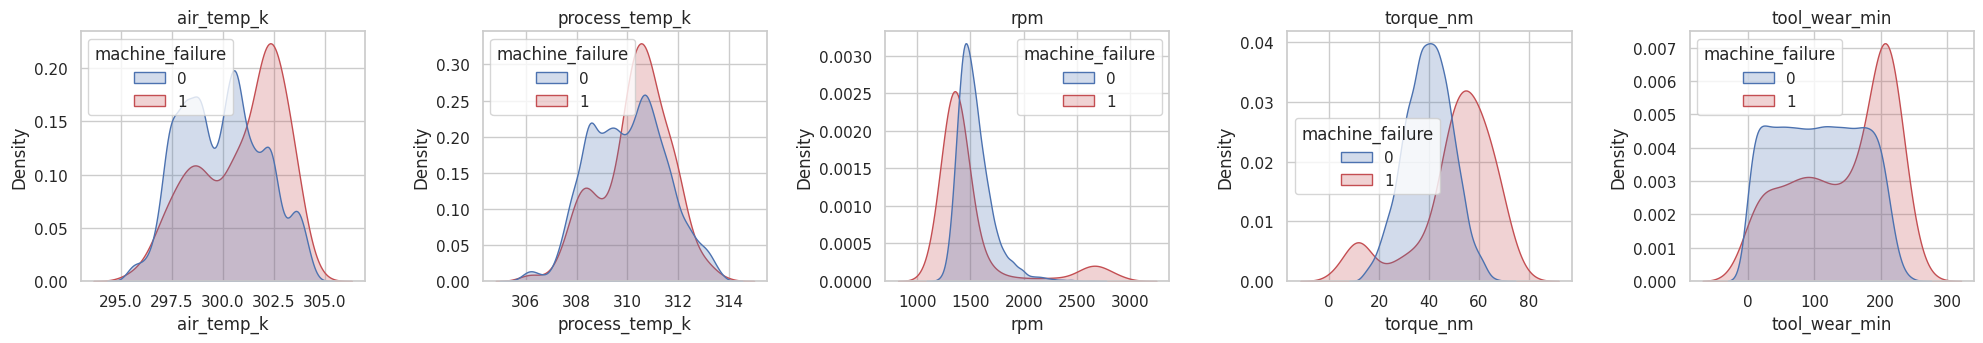

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.6))
for ax, col in zip(axes, SENSOR_COLS):
    sns.kdeplot(data=df, x=col, hue=TARGET, common_norm=False, fill=True, ax=ax, palette=["#4C72B0", "#C44E52"])
    ax.set_title(col)
plt.tight_layout()

Failed machines skew toward **high torque, low rpm, high tool wear and slightly hotter air**. Each one-dimensional view overlaps a lot, so the failures come from *combinations* of conditions.

## 4 · Failure rate by product type

In [7]:
by_type = df.groupby("type")[TARGET].agg(["mean", "sum", "count"]).rename(columns={"mean": "failure_rate", "sum": "failures"})
by_type["failure_rate"] = (by_type["failure_rate"] * 100).round(2)
by_type.loc[["L", "M", "H"]]

,failure_rate,failures,count
type,,,
L,3.92,235,6000
M,2.77,83,2997
H,2.09,21,1003


Low-quality (L) products fail most often. In this dataset L also has the lowest overstrain limit, so wear × torque crosses the danger line sooner.

## 5 · Correlations

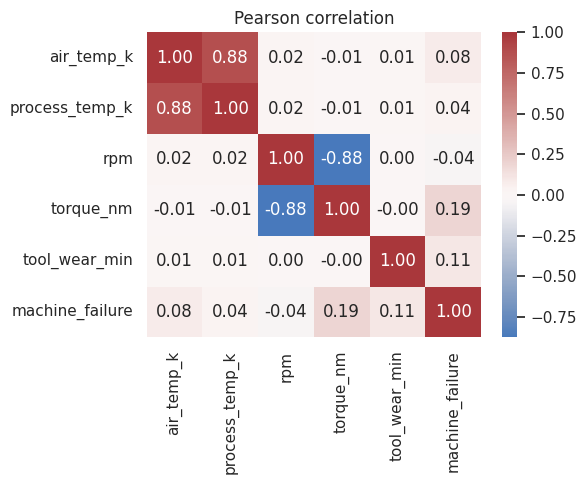

In [8]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[SENSOR_COLS + [TARGET]].corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Pearson correlation"); plt.tight_layout()

- Torque and rotational speed are strongly **negatively** correlated (≈ −0.88): the machine holds roughly constant power, so torque goes up as rpm goes down.
- Air and process temperature are strongly positively correlated (≈ 0.88), because the process heats on top of ambient.
- No single sensor correlates strongly with failure, so linear models will struggle.

## 6 · Physics-based features

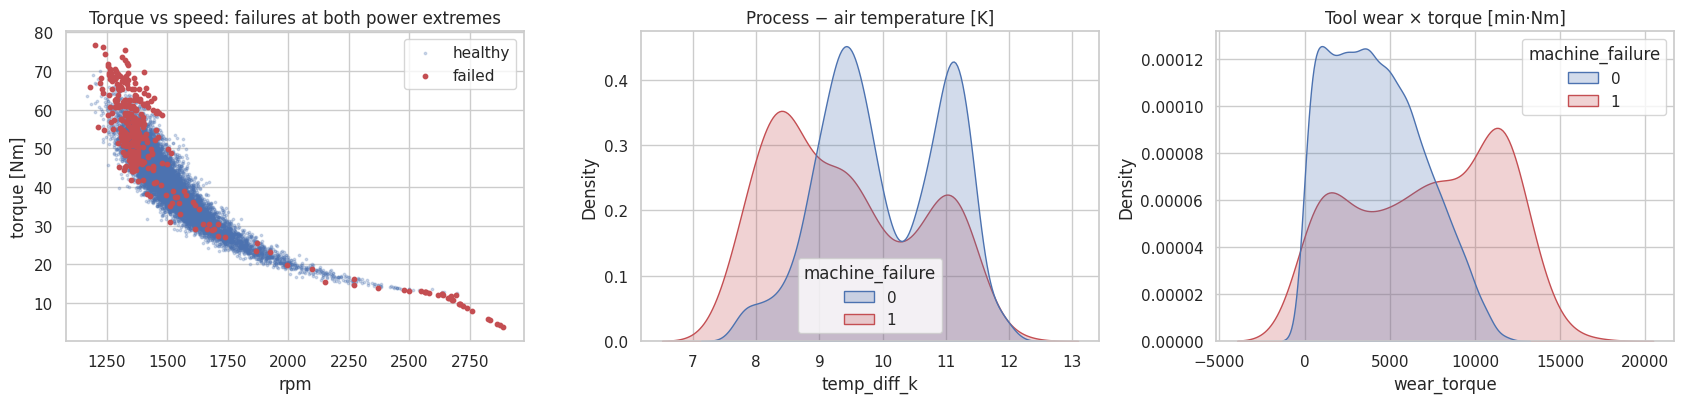

In [9]:
feat = add_features(df)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
healthy, failed = feat[feat[TARGET] == 0], feat[feat[TARGET] == 1]
axes[0].scatter(healthy.rpm, healthy.torque_nm, s=3, alpha=.25, label="healthy")
axes[0].scatter(failed.rpm, failed.torque_nm, s=10, c="#C44E52", label="failed")
axes[0].set(xlabel="rpm", ylabel="torque [Nm]", title="Torque vs speed: failures at both power extremes"); axes[0].legend()
for ax, col, title in [(axes[1], "temp_diff_k", "Process − air temperature [K]"),
                       (axes[2], "wear_torque", "Tool wear × torque [min·Nm]")]:
    sns.kdeplot(data=feat, x=col, hue=TARGET, common_norm=False, fill=True, ax=ax, palette=["#4C72B0", "#C44E52"])
    ax.set_title(title)
plt.tight_layout()

| Feature | Physical meaning | Failure mode it targets |
|---|---|---|
| `temp_diff_k` = process − air | Small gap → heat can't escape | Heat dissipation (HDF) |
| `power_w` = torque × rpm·2π/60 | Mechanical power delivered | Power failure (PWF), both too low and too high |
| `wear_torque` = tool wear × torque | Strain on a worn tool | Overstrain (OSF) |

The scatter shows the failures sitting in the low-power corner (high rpm, low torque) and the high-power corner (low rpm, high torque), which a single straight decision boundary cannot separate.

## Takeaways for modelling
1. Drop the 5 failure flags and the IDs (leakage).
2. Use a stratified split and judge models on recall, precision and PR-AUC, not accuracy.
3. Add the three physics features; expect tree models to beat logistic regression because the failure rules are non-linear thresholds.